# Step 7 - Packaged Trajectory Reconstruction System
This notebook exercises the packaged reconstruction layer from Python and over HTTP.
For normal review, use the saved artifacts and start the API only when you want an active demo.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks','src') else Path.cwd()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project root: {PROJECT_ROOT}')

Project root: c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version


## Part 1: Direct Python Call
This section calls the reconstruction function directly inside the project environment.
Use it to validate the packaged code path without starting the API server.


In [2]:
from aero_fusion.step7_serve import reconstruct_flight, load_flight_catalog

# Load catalog and pick a test flight
catalog = load_flight_catalog()
test_flights = catalog[catalog['split'] == 'test'] if 'split' in catalog.columns else catalog
example_id = str(test_flights['segment_id'].iloc[0])
print(f'Example flight: {example_id}')

Example flight: 20230708_0101e0_115103_124631


In [3]:
# Reconstruct using GRU
try:
    result = reconstruct_flight(example_id, use_gru=True)
except RuntimeError as e:
    # Fallback when GRU checkpoint and model architecture are incompatible
    print(f"GRU load failed ({e.__class__.__name__}). Falling back to baseline reconstruction.")
    result = reconstruct_flight(example_id, use_gru=False)

# Print summary (without the full track list)
summary = {k: v for k, v in result.items() if k not in ('track','gru_waypoints','baseline_waypoints')}
print(json.dumps(summary, indent=2))

[INFO] Model loaded from C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step5_gru\best_model.pt
{
  "segment_id": "20230708_0101e0_115103_124631",
  "method": "gru",
  "gru_available": true,
  "gap_duration_minutes": 226.47,
  "anchor_distance_km": 3483.67,
  "route_distance_km": 5514.81,
  "baseline_route_dist_km": 5509.3,
  "n_track_points": 8800,
  "n_gap_waypoints": 5,
  "processing_ms": 1131,
  "baseline_track": [
    {
      "timestamp": "2023-07-08T10:51:03",
      "latitude": 55.320678,
      "longitude": -0.592429,
      "source": "adsb_before"
    },
    {
      "timestamp": "2023-07-08T10:51:04",
      "latitude": 55.321701,
      "longitude": -0.595443,
      "source": "adsb_before"
    },
    {
      "timestamp": "2023-07-08T10:51:05",
      "latitude": 55.322754,
      "longitude": -0.598755,
      "source": "adsb_before"
    },
    {
      "timestamp": "2023-07-08T10:51:06",
      "latitude": 55.323853,
      "longitude": -0.602148,
      "so

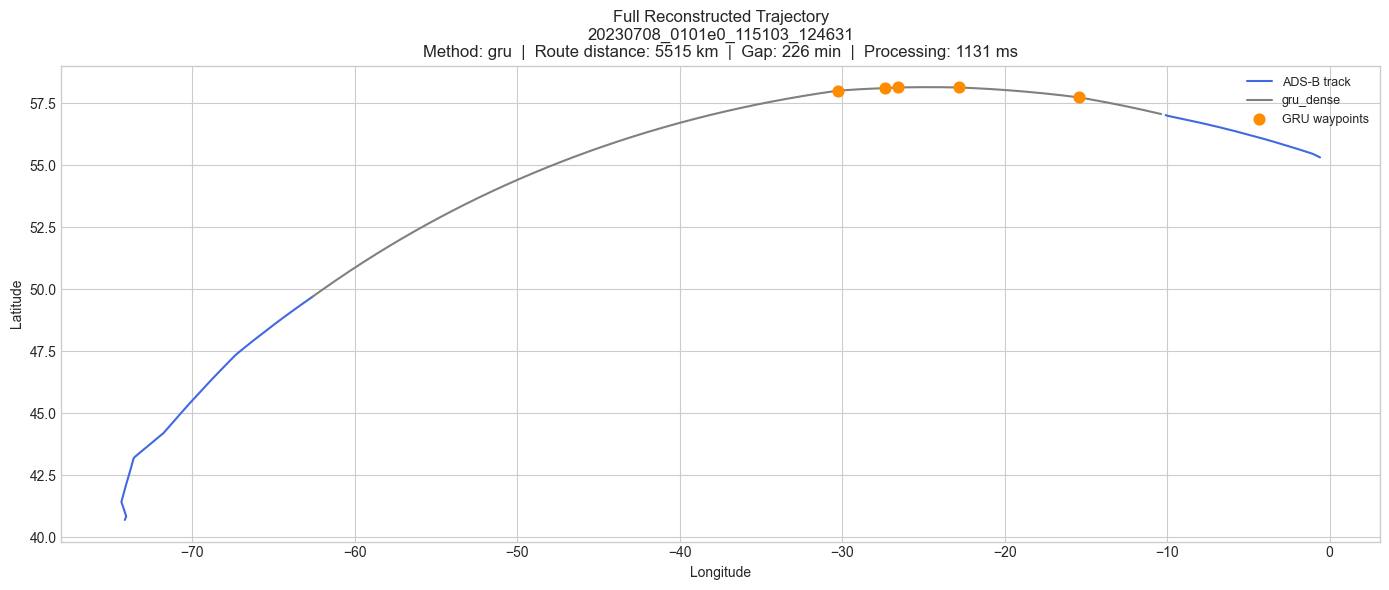

In [4]:
# Plot the full reconstructed trajectory
track = pd.DataFrame(result['track'])
track['timestamp'] = pd.to_datetime(track['timestamp'], format='ISO8601')

gru_wp  = pd.DataFrame(result['gru_waypoints'])       if result['gru_waypoints']      else pd.DataFrame()
base_wp = pd.DataFrame(result['baseline_waypoints'])   if result['baseline_waypoints'] else pd.DataFrame()

fig, ax = plt.subplots(figsize=(14, 6))

colors = {'adsb_before': 'royalblue', 'adsb_after': 'royalblue',
          'gru':        'darkorange', 'baseline':   'red',
          'anchor':     'black'}

for source, group in track.groupby('source'):
    label = {'adsb_before':'ADS-B track','adsb_after':'_nolegend_',
             'gru':'GRU gap fill','baseline':'Baseline gap fill','anchor':'_nolegend_'}.get(source, source)
    lw    = 2.0 if source in ('gru','baseline') else 1.5
    style = '--' if source == 'baseline' else '-'
    ax.plot(group['longitude'], group['latitude'],
            style, color=colors.get(source,'gray'), lw=lw, label=label)

if not gru_wp.empty:
    ax.scatter(gru_wp['longitude'], gru_wp['latitude'],
               s=60, color='darkorange', zorder=5, label='GRU waypoints')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Full Reconstructed Trajectory\n{example_id}\n'
             f'Method: {result["method"]}  |  '
             f'Route distance: {result["route_distance_km"]:.0f} km  |  '
             f'Gap: {result["gap_duration_minutes"]:.0f} min  |  '
             f'Processing: {result["processing_ms"]} ms')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'artifacts' / 'step7_example.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Batch Reconstruction Demo
This batch example shows how the packaged interface behaves across multiple flights.
It is useful for smoke testing catalog loading and output shape.


In [5]:
# Reconstruct 10 test flights and compare GRU vs baseline route distances
sample_ids = test_flights['segment_id'].head(10).tolist()

batch_results = []
for seg_id in sample_ids:
    try:
        r = reconstruct_flight(str(seg_id), use_gru=True)
        b = reconstruct_flight(str(seg_id), use_gru=False)
        batch_results.append({
            'segment_id':           seg_id,
            'gap_duration_min':     r['gap_duration_minutes'],
            'gru_dist_km':          r['route_distance_km'],
            'baseline_dist_km':     b['route_distance_km'],
            'dist_diff_km':         r['route_distance_km'] - b['route_distance_km'],
            'processing_ms':        r['processing_ms'],
        })
        print(f"  {seg_id[:30]} | GRU: {r['route_distance_km']:.0f}km  "
              f"Base: {b['route_distance_km']:.0f}km  "
              f"Diff: {r['route_distance_km']-b['route_distance_km']:+.1f}km  "
              f"({r['processing_ms']}ms)")
    except Exception as exc:
        print(f"  {seg_id}: FAILED — {exc}")

batch_df = pd.DataFrame(batch_results)
print(f"\nBatch complete: {len(batch_df)} flights")
print(f"Mean processing time: {batch_df['processing_ms'].mean():.0f} ms per flight")

  20230708_0101e0_115103_124631 | GRU: 5515km  Base: 5509km  Diff: +5.5km  (671ms)
  20230708_a5d1a2_122902_161821 | GRU: 8499km  Base: 8478km  Diff: +20.3km  (2017ms)
  20230708_ac21af_135232_145532 | GRU: 5552km  Base: 5552km  Diff: +0.1km  (816ms)
  20230708_c02ec1_092844_101850 | GRU: 5028km  Base: 5018km  Diff: +9.7km  (553ms)
  20230709_040187_085652_093702 | GRU: 6362km  Base: 6359km  Diff: +3.3km  (916ms)
  20230709_a0f427_141125_145325 | GRU: 6249km  Base: 6245km  Diff: +3.9km  (637ms)
  20230709_c02ee7_132741_140917 | GRU: 4998km  Base: 4996km  Diff: +1.7km  (537ms)
  20230710_4005c0_153356_160141 | GRU: 5044km  Base: 5035km  Diff: +8.5km  (717ms)
  20230710_aa2ca9_133219_153443 | GRU: 6246km  Base: 6239km  Diff: +7.4km  (573ms)
  20230712_0101db_102630_121307 | GRU: 5783km  Base: 5776km  Diff: +6.6km  (544ms)

Batch complete: 10 flights
Mean processing time: 798 ms per flight


## Part 3: Start the HTTP API Server
This section starts the local API and exercises the served endpoints.
Use it when you want to verify the external interface instead of the direct Python call.


In [6]:
# Run this cell to start the API server
# Then open http://localhost:8000/docs in your browser for the Swagger UI

# NOTE: This will block the notebook. Run it in a terminal instead:
#   python -m aero_fusion.step7_serve

print('To start the API server, run this in a terminal:')
print('  python -m aero_fusion.step7_serve')
print()
print('Then open: http://localhost:8000/docs')
print()
print('Available endpoints:')
print('  GET /health                         — server status')
print('  GET /flights?split=test&limit=20    — list flights')
print('  GET /reconstruct/{segment_id}       — reconstruct one flight')
print('  GET /compare/{segment_id}           — GRU vs baseline side by side')

To start the API server, run this in a terminal:
  python -m aero_fusion.step7_serve

Then open: http://localhost:8000/docs

Available endpoints:
  GET /health                         — server status
  GET /flights?split=test&limit=20    — list flights
  GET /reconstruct/{segment_id}       — reconstruct one flight
  GET /compare/{segment_id}           — GRU vs baseline side by side


In [7]:
# Test the API with HTTP requests (run AFTER starting the server in a terminal)
import urllib.request

BASE_URL = 'http://localhost:8000'

def api_get(endpoint):
    url = f'{BASE_URL}{endpoint}'
    try:
        with urllib.request.urlopen(url, timeout=30) as resp:
            return json.loads(resp.read())
    except Exception as e:
        return {'error': str(e)}

# Health check
health = api_get('/health')
print('Health:', json.dumps(health, indent=2))

Health: {
  "error": "<urlopen error [WinError 10061] No connection could be made because the target machine actively refused it>"
}


In [8]:
# List test flights via API
flights = api_get('/flights?split=test&limit=5')
print(json.dumps(flights, indent=2))

{
  "error": "<urlopen error [WinError 10061] No connection could be made because the target machine actively refused it>"
}


In [9]:
# Reconstruct a flight via HTTP
api_result = api_get(f'/reconstruct/{example_id}')

if 'error' not in api_result:
    summary = {k: v for k, v in api_result.items()
               if k not in ('track','gru_waypoints','baseline_waypoints')}
    print(json.dumps(summary, indent=2))
    print(f'\nTrack has {len(api_result["track"])} points')
else:
    print('API not running. Start server first: python -m aero_fusion.step7_serve')

API not running. Start server first: python -m aero_fusion.step7_serve


## Summary
The Step 7 package should expose the same reconstruction behavior through both entry points.
Keep this notebook in review mode unless you intentionally want to launch the live API demo.


In [10]:
print('='*60)
print('STEP 7 — SYSTEM PACKAGING SUMMARY')
print('='*60)
print()
print('API endpoints:')
print('  /health           — model loaded, system status')
print('  /flights          — browse available flights')
print('  /reconstruct/{id} — full trajectory reconstruction')
print('  /compare/{id}     — GRU vs baseline comparison')
print()
if batch_results:
    print(f'Batch demo ({len(batch_df)} flights):')
    print(f'  Mean processing time : {batch_df["processing_ms"].mean():.0f} ms')
    print(f'  Mean route distance  : {batch_df["gru_dist_km"].mean():.0f} km (GRU)')
    print(f'  Mean dist difference : {batch_df["dist_diff_km"].mean():+.1f} km vs baseline')
print()
print('The system answers the project question:')
print('  "Given this long-haul flight with missing track segments,')
print('   what is the most reasonable reconstructed path?"')
print('='*60)

STEP 7 — SYSTEM PACKAGING SUMMARY

API endpoints:
  /health           — model loaded, system status
  /flights          — browse available flights
  /reconstruct/{id} — full trajectory reconstruction
  /compare/{id}     — GRU vs baseline comparison

Batch demo (10 flights):
  Mean processing time : 798 ms
  Mean route distance  : 5928 km (GRU)
  Mean dist difference : +6.7 km vs baseline

The system answers the project question:
  "Given this long-haul flight with missing track segments,
   what is the most reasonable reconstructed path?"
